# Malliavin Calculus: Stochastic Calculus of Variations

## What is it?
**Malliavin Calculus** extends the notion of differentiation to **functionals of Brownian paths**. If ordinary calculus asks "how does $f(x)$ change when $x$ moves?", Malliavin calculus asks "how does $F(W)$ change when the Brownian path $W$ is perturbed?"

## The Malliavin Derivative $D_t F$
For a functional $F$ of the Brownian path up to time $T$, the Malliavin derivative $D_t F$ is a stochastic process indexed by $t \in [0,T]$ that measures the sensitivity of $F$ to an infinitesimal perturbation of $W_t$ at time $t$.

### Basic Rules
- **Linearity:** $D_t(aF + bG) = a D_t F + b D_t G$
- **Chain rule:** $D_t f(W_T) = f'(W_T) \cdot D_t W_T = f'(W_T) \cdot \mathbf{1}_{[0,T]}(t)$
- **Product rule:** $D_t(FG) = F D_t G + G D_t F$

### Examples
| Functional $F$ | Malliavin Derivative $D_t F$ |
|----------------|------------------------------|
| $W_T$ | $1$ (for $t \leq T$) |
| $W_T^2$ | $2 W_T$ |
| $\int_0^T W_s\,ds$ | $\int_t^T ds = T - t$ |
| $e^{W_T}$ | $e^{W_T}$ |

## Cameron-Martin Space
Perturbations of Brownian paths must belong to the Cameron-Martin space (absolutely continuous functions with square-integrable derivative). If $h(t) = \int_0^t \dot{h}_s\,ds$, then:
$$\left.\frac{d}{d\epsilon}F(W + \epsilon h)\right|_{\epsilon=0} = \int_0^T D_t F \cdot \dot{h}_t\,dt$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# ============ GLOBAL PARAMETERS ============
T = 1.0
N = 500
dt = T / N
t = np.linspace(0, T, N + 1)
n_paths = 8
eps = 0.3


## Visualization 1: Path Perturbations and Directional Derivatives

A functional $F$ maps an entire Brownian path to a real number (e.g., $F(W) = W_T$ or $F(W) = \max(W_T - K, 0)$).

The **directional derivative** in direction $h$ (Cameron-Martin) is:
$$\lim_{\epsilon \to 0} \frac{F(W + \epsilon h) - F(W)}{\epsilon}$$

For $h(t) = t$ (so $\dot{h} = 1$), this equals $\int_0^T D_t F\,dt$.

**Left panel:** Original Brownian paths and their perturbations.  
**Right panel:** The functional $F(W) = \max(W_T - K, 0)$ and its directional derivative for each path.


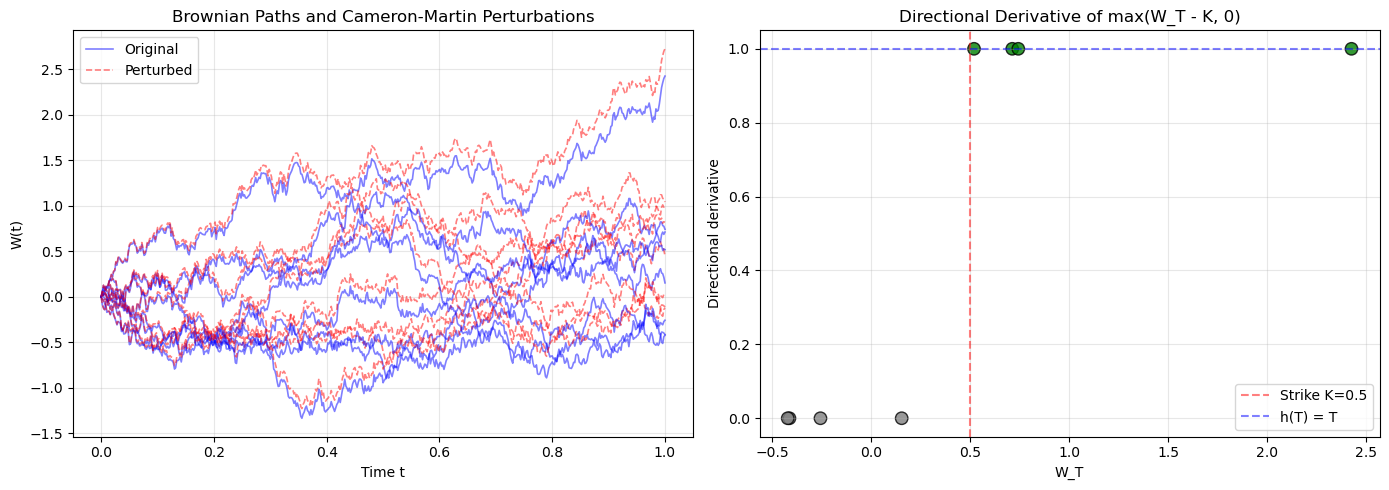

In [2]:
# ============ PLOT 1: Path Perturbations ============
dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
W = np.zeros((n_paths, N + 1))
W[:, 1:] = np.cumsum(dW, axis=1)

# Cameron-Martin direction h(t) = t
h = t

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: original and perturbed paths
ax = axes[0]
for i in range(n_paths):
    ax.plot(t, W[i], 'b-', alpha=0.5, linewidth=1.2, label='Original' if i == 0 else '')
    ax.plot(t, W[i] + eps * h, 'r--', alpha=0.5, linewidth=1.2, label='Perturbed' if i == 0 else '')
ax.set_title('Brownian Paths and Cameron-Martin Perturbations', fontsize=12)
ax.set_xlabel('Time t')
ax.set_ylabel('W(t)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: directional derivative of F(W) = max(W_T - K, 0)
K = 0.5
F_orig = np.maximum(W[:, -1] - K, 0)
F_pert = np.maximum((W[:, -1] + eps * h[-1]) - K, 0)
dir_deriv = (F_pert - F_orig) / eps

ax = axes[1]
colors = ['green' if W[i, -1] > K else 'gray' for i in range(n_paths)]
ax.scatter(W[:, -1], dir_deriv, c=colors, s=80, alpha=0.8, edgecolors='black')
ax.axvline(K, color='red', linestyle='--', alpha=0.5, label='Strike K=' + str(K))
ax.axhline(h[-1], color='blue', linestyle='--', alpha=0.5, label='h(T) = T')
ax.set_title('Directional Derivative of max(W_T - K, 0)', fontsize=12)
ax.set_xlabel('W_T')
ax.set_ylabel('Directional derivative')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## The Malliavin Derivative as a Stochastic Process

Unlike ordinary derivatives, $D_t F$ is a **process** indexed by $t$. For a fixed $\omega$ (path realization), $D_t F(\omega)$ is a function of $t$.

**Key insight:** For functionals that depend only on $W_T$, the derivative is **constant in $t$** (for $t \in [0,T]$), because perturbing $W$ at any time $t \leq T$ affects $W_T$ equally.

For functionals depending on the entire path (like $\int_0^T W_s\,ds$), the derivative varies with $t$.


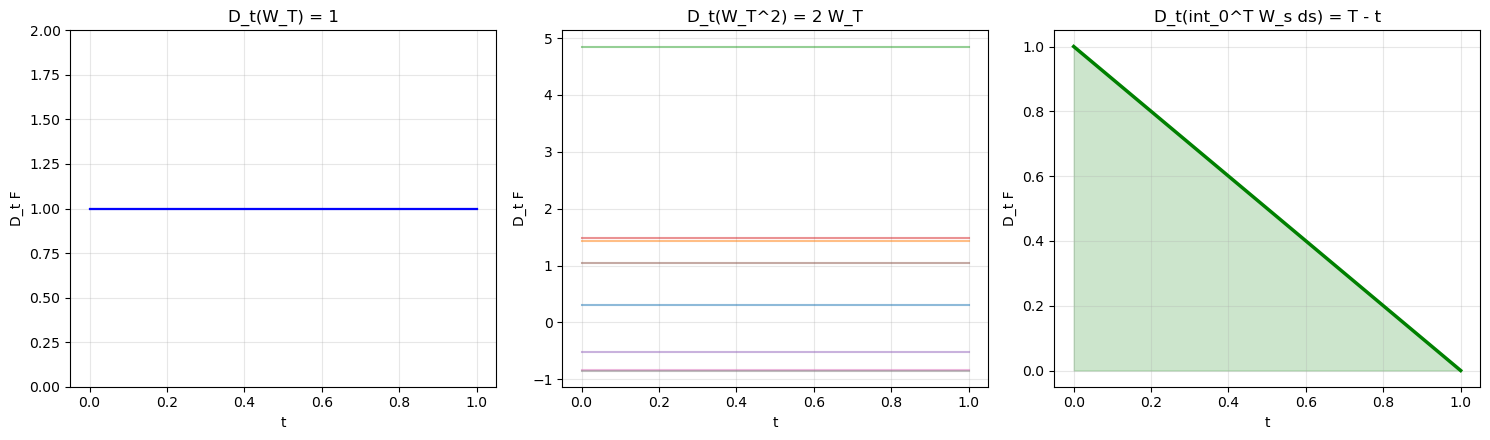

In [3]:
# ============ PLOT 2: Malliavin Derivative Processes ============
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# F = W_T  =>  D_t F = 1
ax = axes[0]
for i in range(n_paths):
    ax.plot(t, np.ones_like(t), 'b-', alpha=0.4, linewidth=1.5)
ax.set_title('D_t(W_T) = 1', fontsize=12)
ax.set_xlabel('t')
ax.set_ylabel('D_t F')
ax.set_ylim(0, 2)
ax.grid(True, alpha=0.3)

# F = W_T^2  =>  D_t F = 2 W_T
ax = axes[1]
for i in range(n_paths):
    Dt_F = 2 * W[i, -1] * np.ones_like(t)
    ax.plot(t, Dt_F, alpha=0.5, linewidth=1.5)
ax.set_title('D_t(W_T^2) = 2 W_T', fontsize=12)
ax.set_xlabel('t')
ax.set_ylabel('D_t F')
ax.grid(True, alpha=0.3)

# F = integral_0^T W_s ds  =>  D_t F = T - t
ax = axes[2]
Dt_F_int = T - t
ax.plot(t, Dt_F_int, 'g-', linewidth=2.5)
ax.fill_between(t, 0, Dt_F_int, alpha=0.2, color='green')
ax.set_title(r'D_t(int_0^T W_s ds) = T - t', fontsize=12)
ax.set_xlabel('t')
ax.set_ylabel('D_t F')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Integration by Parts and the Skorohod Integral

The **Skorohod integral** $\delta(u)$ is the adjoint of the Malliavin derivative. It generalizes the Ito integral to non-adapted (anticipating) integrands.

### Integration by Parts Formula
For a smooth functional $F$ and an adapted process $u_t$:
$$\mathbb{E}\left[ F \int_0^T u_t\,dW_t \right] = \mathbb{E}\left[ \int_0^T (D_t F)\,u_t\,dt \right]$$

This is the workhorse for **Greeks computation**: instead of differentiating the payoff (which may be non-differentiable, e.g., a digital option), we transfer the derivative to a smooth weight function using integration by parts.

## Application: Malliavin Delta for European Options

For a European call in Black-Scholes:
$$S_T = S_0 \exp\left(\left(r - \tfrac{1}{2}\sigma^2\right)T + \sigma W_T\right)$$

The Malliavin weight for Delta is:
$$\pi = \frac{W_T}{S_0 \sigma T}$$

So:
$$\Delta = e^{-rT}\,\mathbb{E}\left[ (S_T - K)^+ \cdot \frac{W_T}{S_0 \sigma T} \right]$$

**Advantage:** The payoff $(S_T - K)^+$ is not differentiable at $K$, but the Malliavin formula avoids ever differentiating it.


Exact BS Delta:     0.636831
Malliavin Delta:    0.638402
Finite Difference:  0.637357


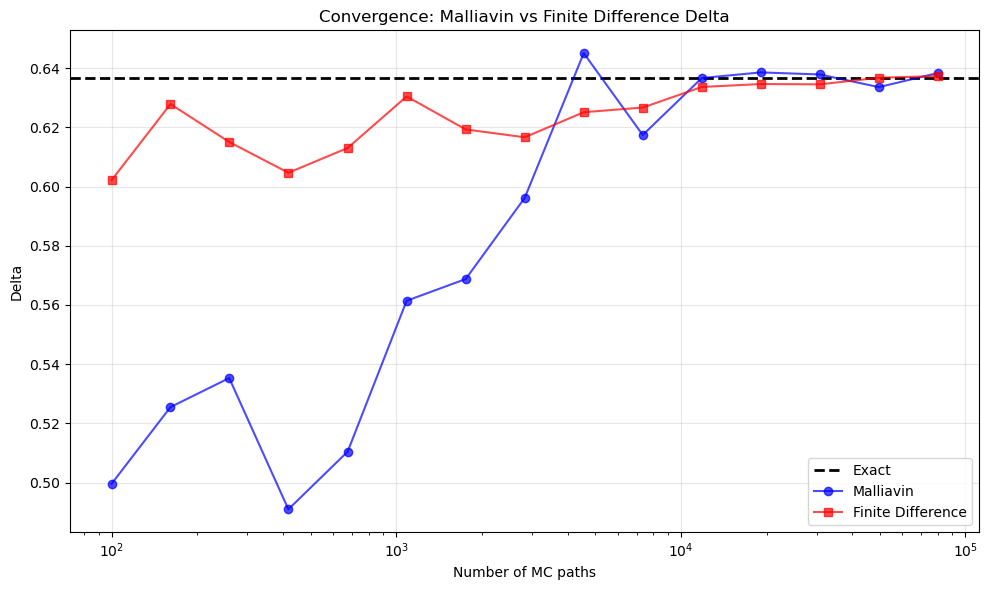

In [4]:
# ============ PLOT 3: Delta via Malliavin vs Finite Difference ============
S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T_bs = 1.0
h_fd = 1.0  # finite difference bump
n_mc = 80000

# Common random numbers for fair comparison
W_T = np.random.standard_normal(n_mc) * np.sqrt(T_bs)

def terminal_spot(S0_val, W):
    return S0_val * np.exp((r - 0.5 * sigma**2) * T_bs + sigma * W)

S = terminal_spot(S0, W_T)
payoff = np.maximum(S - K, 0)

# Malliavin Delta
delta_malliavin = np.exp(-r * T_bs) * np.mean(payoff * W_T / (S0 * sigma * T_bs))

# Finite Difference Delta (common random numbers)
S_plus = terminal_spot(S0 + h_fd, W_T)
S_minus = terminal_spot(S0 - h_fd, W_T)
delta_fd = (np.exp(-r * T_bs)
            * np.mean(np.maximum(S_plus - K, 0) - np.maximum(S_minus - K, 0))
            / (2 * h_fd))

# Exact Black-Scholes Delta
d1_exact = ((np.log(S0 / K) + (r + 0.5 * sigma**2) * T_bs)
            / (sigma * np.sqrt(T_bs)))
delta_exact = norm.cdf(d1_exact)

print("Exact BS Delta:     {:.6f}".format(delta_exact))
print("Malliavin Delta:    {:.6f}".format(delta_malliavin))
print("Finite Difference:  {:.6f}".format(delta_fd))

# Convergence analysis
n_vals = np.unique(np.logspace(2, np.log10(n_mc), 15).astype(int))
delta_mall_conv = []
delta_fd_conv = []

for n in n_vals:
    W_n = W_T[:n]
    S_n = terminal_spot(S0, W_n)
    pay_n = np.maximum(S_n - K, 0)
    delta_mall_conv.append(np.exp(-r * T_bs)
                           * np.mean(pay_n * W_n / (S0 * sigma * T_bs)))
    
    S_p = terminal_spot(S0 + h_fd, W_n)
    S_m = terminal_spot(S0 - h_fd, W_n)
    delta_fd_conv.append(np.exp(-r * T_bs)
                         * np.mean(np.maximum(S_p - K, 0) - np.maximum(S_m - K, 0))
                         / (2 * h_fd))

fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(delta_exact, color='black', linestyle='--', linewidth=2, label='Exact')
ax.plot(n_vals, delta_mall_conv, 'o-', color='blue', label='Malliavin', alpha=0.7)
ax.plot(n_vals, delta_fd_conv, 's-', color='red', label='Finite Difference', alpha=0.7)
ax.set_xscale('log')
ax.set_title('Convergence: Malliavin vs Finite Difference Delta', fontsize=12)
ax.set_xlabel('Number of MC paths')
ax.set_ylabel('Delta')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Clark-Ocone Representation Theorem

Any square-integrable, $\mathcal{F}_T$-measurable random variable $F$ can be written as:
$$F = \mathbb{E}[F] + \int_0^T \mathbb{E}\left[ D_t F \,\big|\, \mathcal{F}_t \right] dW_t$$

### Interpretation for Finance
For a contingent claim with payoff $F$ at time $T$:
- $\mathbb{E}[F]$ is the fair price at $t=0$ (under risk-neutral measure).
- $\mathbb{E}[D_t F | \mathcal{F}_t]$ is the **replicating hedge ratio** at time $t$.

For a European call in Black-Scholes:
$$\mathbb{E}\left[ D_t (e^{-rT}(S_T - K)^+) \,\big|\, \mathcal{F}_t \right] = e^{-rt} \sigma S_t \,N(d_1(t, S_t))$$

And the discounted option value satisfies:
$$e^{-rt} V(t, S_t) = V(0, S_0) + \int_0^t e^{-rs} \sigma S_s \,N(d_1(s, S_s))\, dW_s$$

**Left panel:** Simulated stock path.  
**Middle panel:** The hedge ratio $\phi_t = N(d_1(t, S_t))$ along the path.  
**Right panel:** The cumulative integral tracks the discounted option value perfectly.


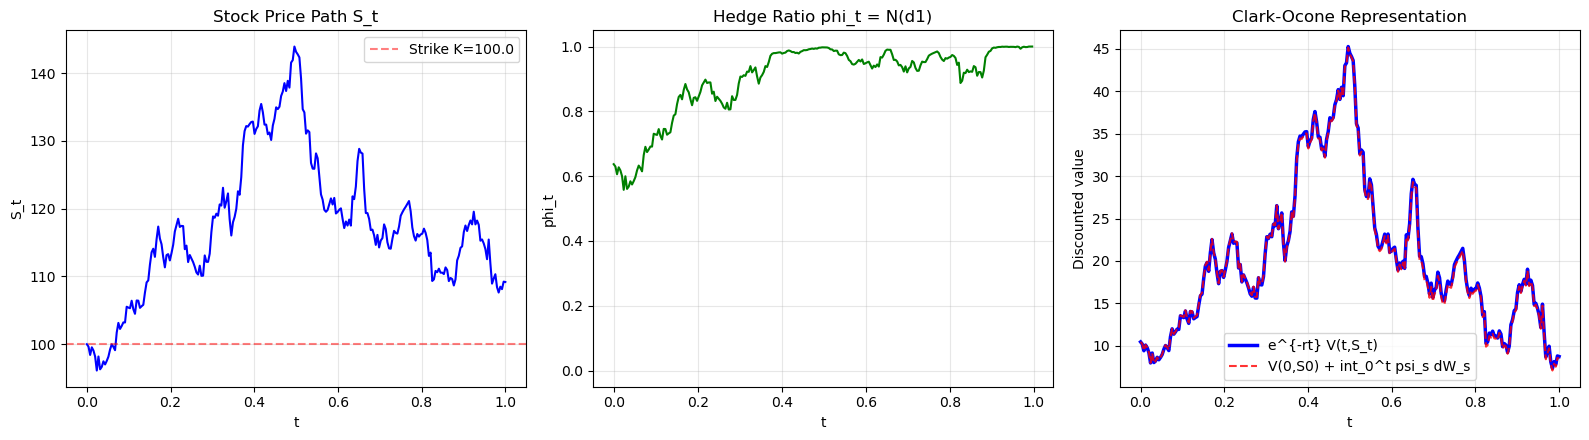

Final verification:
V(0,S0)           = 10.450584
Discounted payoff = 8.726780
M0 + total int    = 8.498572


In [5]:
# ============ PLOT 4: Clark-Ocone Representation ============
N_co = 252
dt_co = T / N_co
t_co = np.linspace(0, T, N_co + 1)

# Simulate one stock path under risk-neutral measure
dW_co = np.random.normal(0, np.sqrt(dt_co), size=N_co)
W_co = np.zeros(N_co + 1)
W_co[1:] = np.cumsum(dW_co)

S_co = np.zeros(N_co + 1)
S_co[0] = S0
for i in range(N_co):
    S_co[i + 1] = S_co[i] * np.exp((r - 0.5 * sigma**2) * dt_co + sigma * dW_co[i])

# Black-Scholes price V(t, S_t) along the path
V_path = np.zeros(N_co + 1)
phi = np.zeros(N_co)
for i in range(N_co + 1):
    tau = T - t_co[i]
    if tau > 1e-10:
        d1_val = ((np.log(S_co[i] / K) + (r + 0.5 * sigma**2) * tau)
                  / (sigma * np.sqrt(tau)))
        d2_val = d1_val - sigma * np.sqrt(tau)
        V_path[i] = (S_co[i] * norm.cdf(d1_val)
                     - K * np.exp(-r * tau) * norm.cdf(d2_val))
    else:
        V_path[i] = np.maximum(S_co[i] - K, 0)

# Hedge ratio phi_t = N(d1) for t < T
for i in range(N_co):
    tau = T - t_co[i]
    if tau > 1e-10:
        d1_val = ((np.log(S_co[i] / K) + (r + 0.5 * sigma**2) * tau)
                  / (sigma * np.sqrt(tau)))
        phi[i] = norm.cdf(d1_val)
    else:
        phi[i] = 1.0 if S_co[i] > K else 0.0

# Clark-Ocone: e^{-rt} V(t,S_t) = V(0,S_0) + int_0^t e^{-rs} phi_s sigma S_s dW_s
discounted_V = np.exp(-r * t_co) * V_path
cumulative = np.zeros(N_co + 1)
for i in range(N_co):
    integrand = np.exp(-r * t_co[i]) * sigma * S_co[i] * phi[i]
    cumulative[i + 1] = cumulative[i] + integrand * dW_co[i]

M0 = V_path[0]  # = discounted_V[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(t_co, S_co, 'b-', linewidth=1.5)
ax.axhline(K, color='red', linestyle='--', alpha=0.5, label='Strike K=' + str(K))
ax.set_title('Stock Price Path S_t', fontsize=12)
ax.set_xlabel('t')
ax.set_ylabel('S_t')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t_co[:-1], phi, 'g-', linewidth=1.5)
ax.set_title('Hedge Ratio phi_t = N(d1)', fontsize=12)
ax.set_xlabel('t')
ax.set_ylabel('phi_t')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(t_co, discounted_V, 'b-', linewidth=2.5, label='e^{-rt} V(t,S_t)')
ax.plot(t_co, M0 + cumulative, 'r--', linewidth=1.5, alpha=0.8,
        label='V(0,S0) + int_0^t psi_s dW_s')
ax.set_title('Clark-Ocone Representation', fontsize=12)
ax.set_xlabel('t')
ax.set_ylabel('Discounted value')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Final verification:")
print("V(0,S0)           = {:.6f}".format(M0))
print("Discounted payoff = {:.6f}".format(discounted_V[-1]))
print("M0 + total int    = {:.6f}".format(M0 + cumulative[-1]))


## Summary

| Concept | Meaning |
|---------|---------|
| $D_t F$ | Sensitivity of $F$ to perturbation of $W$ at time $t$ |
| Cameron-Martin | Admissible directions for path perturbations |
| Skorohod integral $\delta(u)$ | Adjoint of $D_t$; generalizes Ito integral |
| Integration by parts | Transfers derivatives from payoff to smooth weights |
| Clark-Ocone | Any $F_T$-measurable $F$ is an Ito integral of its conditional derivative |

## Why it matters
1. **Greeks for exotic options:** Malliavin weights give unbiased estimators for sensitivities even when payoffs are discontinuous (digitals, barriers).
2. **Hedging:** The Clark-Ocone integrand is the exact replicating strategy.
3. **Density estimation:** Malliavin calculus yields formulas for probability densities of diffusions without solving PDEs.
4. **Stochastic control:** Appears in maximum principles and Pontryagin-type conditions.

## Key Takeaway
> *"Malliavin calculus lets you differentiate inside expectations by differentiating the probability measure instead of the payoff."*
